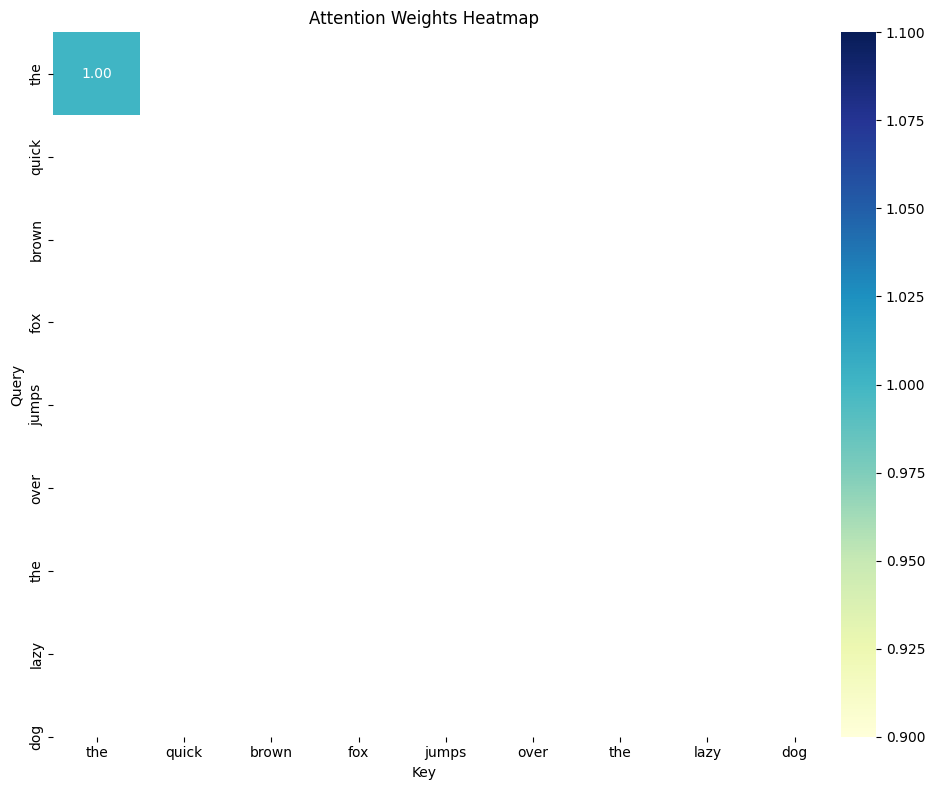

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

class SimpleTokenizer:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.vocab_size = 0
    
    def tokenize(self, text):
        # Simple whitespace tokenization
        tokens = text.split()
        
        # Build vocabulary if not exists
        for token in tokens:
            if token not in self.word2idx:
                self.word2idx[token] = self.vocab_size
                self.idx2word[self.vocab_size] = token
                self.vocab_size += 1
        
        # Convert to indices
        return [self.word2idx[token] for token in tokens]

class SimpleAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_size=64, num_heads=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = nn.MultiheadAttention(embed_size, num_heads)
        self.layer_norm = nn.LayerNorm(embed_size)
    
    def forward(self, x):
        # Embed the input
        x = self.embedding(x)
        
        # Apply attention
        attn_output, attn_weights = self.attention(x, x, x)
        
        # Normalize
        x = self.layer_norm(x + attn_output)
        
        return x, attn_weights

def visualize_attention(attention_weights, tokens):
    plt.figure(figsize=(10, 8))
    
    # Convert to numpy and select first head's attention weights
    weights_np = attention_weights[0].detach().numpy()
    
    sns.heatmap(weights_np, 
                cmap="YlGnBu", 
                xticklabels=tokens, 
                yticklabels=tokens,
                annot=True,  # Show numeric values
                fmt='.2f')   # Format to 2 decimal places
    
    plt.title("Attention Weights Heatmap")
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.tight_layout()
    plt.show()

def main():
    # Create tokenizer
    tokenizer = SimpleTokenizer()
    
    # Example text
    text = "the quick brown fox jumps over the lazy dog"
    
    # Tokenize text
    tokens_idx = tokenizer.tokenize(text)
    
    # Convert to tensor
    sequence = torch.tensor(tokens_idx).unsqueeze(0)  # Add batch dimension
    
    # Create model
    model = SimpleAttentionModel(tokenizer.vocab_size)
    
    # Forward pass to get attention weights
    _, attention_weights = model(sequence)
    
    # Visualize attention
    visualize_attention(attention_weights, 
                        [tokenizer.idx2word[idx] for idx in tokens_idx])

# Uncomment to run
main()